# 7. Indicator Kriging 


**Dataset:** Meuse floodplain soil survey (`data/meuse.csv`, 155 samples) + prediction grid (`data/meuse_grid.csv`)

**Target:** Zinc (`zinc`, ppm)

**Library:** `pygstat.indicator_kriging` — ordinary indicator kriging in the GSLIB `ik3d` family (Deutsch & Journel, *GSLIB*, 2nd ed.)


***
## Table of Contents

1. [Overview](#1-overview)
2. [Theory - Indicator Transform and Exceedance Probability](#2-theory--indicator-transform-and-exceedance-probability)
3. [Theory - Indicator Variograms](#3-theory--indicator-variograms)
4. [Theory - The Indicator Kriging System](#4-theory--the-indicator-kriging-system)
5. [Theory - Conditional CDF and E-type Estimates](#5-theory--conditional-cdf-and-e-type-estimates)
6. [Python Setup](#6-python-setup)
7. [Load and Explore the Meuse Zinc Data](#7-load-and-explore-the-meuse-zinc-data)
8. [Choose Cutoffs and Build Indicators](#8-choose-cutoffs-and-build-indicators)
9. [Empirical Indicator Variograms](#9-empirical-indicator-variograms)
10. [Cross-Validation (Brier Score)](#10-cross-validation-brier-score)
11. [Predict Exceedance Probabilities on the Grid](#11-predict-exceedance-probabilities-on-the-grid)
12. [E-type Estimate of Zinc](#12-e-type-estimate-of-zinc)
13. [CPU vs GPU IK Timing](#13-cpu-vs-gpu-ik-timing)
14. [Summary and Conclusions](#14-summary-and-conclusions)
15. [Resources](#15-resources)


***
## 1. Overview

**Indicator Kriging (IK)** is a non-parametric interpolator: instead of kriging the
continuous variable $Z(\mathbf{x})$ itself, it kriges a family of binary
*indicators* $I(\mathbf{x}; z_k)$ that record whether $Z$ exceeds a cutoff $z_k$.
The kriged indicator is an estimate of the **exceedance probability**
$P[Z(\mathbf{x}_0) \ge z_k]$. Stacking several cutoffs builds a local conditional
distribution, from which an **E-type** (expected-value) map of zinc can be
recovered without assuming Gaussianity.

That matters for Meuse zinc. The 155 floodplain samples are **right-skewed**
(min 113 ppm, median 326 ppm, max 1 839 ppm). Ordinary kriging of the raw grades
would smear the high-grade river-bank samples across the floodplain and would
need a Gaussian assumption to turn $(\hat{Z}, \sigma_K)$ into exceedance
probabilities. Indicator kriging does neither: each cutoff has its own
variogram, so the spatial continuity of “high zinc” can differ from that of
“moderate zinc”.

GSLIB’s `ik3d` (Deutsch & Journel, *GSLIB: Geostatistical Software Library*,
2nd ed.) is the reference implementation. **`pygstat.IndicatorKriging`** is the
library’s ordinary-indicator engine for 2-D point data — the same linear system
as `ik3d`’s ordinary-kriging branch, with per-threshold spherical or exponential
covariance, a local search neighborhood, and probabilities clipped to $[0, 1]$.

| Step | What we do |
|---|---|
| Data | Load `meuse.csv` (155 samples) and `meuse_grid.csv` (~3 100 floodplain nodes) |
| Cutoffs | Nine zinc quantiles (10%–90%); skip 0% / 100% (degenerate indicators) |
| Indicator variograms | Empirical $\gamma_I(h; z_k)$ and a spherical fit at each cutoff |
| Cross-validation | 5-fold Brier score vs a no-skill (marginal frequency) baseline |
| Mapping | $P(\mathrm{Zn} \ge z_k)$ on the Meuse grid at the 10th, 50th, and 90th percentiles |
| E-type | Expected zinc from the local ccdf via `compute_etype_from_probabilities` |

| CPU / GPU | Time k-NN `IndicatorKriging` on CPU vs GPU using **sgsim** Meuse-like zinc ($n=8{,}000$) |

By the end you will have probability maps of zinc exceedance, a Brier-score
check that IK beats a naive baseline, an E-type map that can be compared
with ordinary kriging of the raw grades, and a CPU vs GPU timing of the
batched k-NN IK solve on a simulated Meuse field with $n > 5{,}000$.


***
## 2. Theory - Indicator Transform and Exceedance Probability

Let $Z(\mathbf{x})$ be the continuous grade (zinc, ppm) at location
$\mathbf{x} = (x, y)$. For a cutoff $z_k$, the **indicator** used by
`pygstat.IndicatorKriging` is the exceedance coding

$$
I(\mathbf{x}; z_k) =
\begin{cases}
1, & Z(\mathbf{x}) \ge z_k \\
0, & Z(\mathbf{x}) < z_k .
\end{cases}
$$

(GSLIB `ik3d` more often stores the complementary cdf coding
$I(\mathbf{x}; z_k) = 1$ if $Z \le z_k$; the two are equivalent up to a flip,
$P[Z \ge z_k] = 1 - F(z_k^-)$.) Taking expectation,

$$
\mathbb{E}\big[I(\mathbf{x}_0; z_k)\big] = P\big[Z(\mathbf{x}_0) \ge z_k\big].
$$

Ordinary kriging of the $0/1$ data is therefore a **direct estimator of the
exceedance probability**. The estimate $I^*(\mathbf{x}_0; z_k)$ is clipped to
$[0, 1]$ after solving the kriging system, because a raw linear combination of
indicators is not guaranteed to stay inside the probability interval.

A small worked example with cutoff $z_k = 10$:

| Location | $Z(\mathbf{x}_i)$ | $I(\mathbf{x}_i; 10)$ |
|---|---|---|
| A | 5 | 0 |
| B | 20 | 1 |
| C | 15 | 1 |

Kriging those three 0/1 values at an unsampled point yields
$P[Z \ge 10]$ there — not an estimate of the grade itself.


***
## 3. Theory - Indicator Variograms

Each cutoff has its **own** spatial continuity. High-grade zinc along the Meuse
river may be more nuggety (or more anisotropic) than the mid-grade background,
so a single variogram of $Z$ is the wrong covariance for every probability map.
The experimental indicator semivariogram at cutoff $z_k$ is the usual Matheron
estimator applied to $I(\cdot; z_k)$:

$$
\gamma_I(h; z_k)
= \frac{1}{2N(h)}
\sum_{N(h)}
\big[I(\mathbf{x}_i; z_k) - I(\mathbf{x}_i + \mathbf{h}; z_k)\big]^2 .
$$

Two useful identities follow at once:

- $\gamma_I$ is identical for $I$ and $1-I$ (squared differences do not change),
  so the empirical curve from `fit_indicator_variogram` (which uses
  $I(Z \le z_k)$) can be used as the covariance model for
  `IndicatorKriging` (which uses $I(Z \ge z_k)$).
- The theoretical sill of a binary indicator is $p_k(1-p_k)$, where
  $p_k = P[Z \ge z_k]$. Extreme cutoffs ($p_k \to 0$ or $1$) have almost no
  variance and noisy empirical variograms — which is why we drop the 0% and
  100% quantiles.

This notebook fits a **spherical** model at each cutoff,

$$
\gamma(h) =
\begin{cases}
c_0 + c\bigl(1.5\,h/a - 0.5\,(h/a)^3\bigr), & h < a \\
c_0 + c, & h \ge a,
\end{cases}
$$

and passes the triple $(c_0, c, a)$ to `IndicatorKriging.predict` as
`variogram_params[z_k]`. The corresponding covariance used in the kriging
system is $C(h) = C(0) - \gamma(h)$, implemented as
`_spherical_covariance` in `pygstat.indicator_kriging`.


***
## 4. Theory - The Indicator Kriging System

At a target $\mathbf{x}_0$, ordinary indicator kriging uses the $n$ neighbouring
indicators inside a search radius (capped at `max_neighbors`) and solves the
same OK system as Tutorial 04, but with the **indicator covariance** $C_I$:

$$
\begin{pmatrix}
C_I & \mathbf{1} \\
\mathbf{1}^\top & 0
\end{pmatrix}
\begin{pmatrix} \boldsymbol\lambda \\ \mu \end{pmatrix}
=
\begin{pmatrix} \mathbf{c}_{I,0} \\ 1 \end{pmatrix},
\qquad
I^*(\mathbf{x}_0; z_k)
= \sum_{i=1}^{n} \lambda_i\, I(\mathbf{x}_i; z_k).
$$

The extra row $\sum_i \lambda_i = 1$ (Lagrange multiplier $\mu$) makes the
estimator unbiased for an unknown local mean — here the unknown local
exceedance rate. `pygstat.IndicatorKriging` solves this with
`scipy.linalg.solve` (symmetric) and falls back to least squares if the
neighbourhood is degenerate. After clipping,

$$
I^*(\mathbf{x}_0; z_k) \;\approx\; P\big[Z(\mathbf{x}_0) \ge z_k\big] \in [0, 1].
$$

**Search neighbourhood.** Distant 0/1 samples should not inform a local
probability (and they make $C_I$ large and ill-conditioned). The implementation
builds a `cKDTree` on the (optionally anisotropically transformed) coordinates
and keeps at most `max_neighbors` points inside `search_radius`. Geometric
anisotropy is the usual 2-D rotation-and-range-ratio transform
(`anisotropy_angle`, `anisotropy_ratio`).

**Simple numerical example of why order relations matter.** Nothing in the
linear system forces $I^*(\mathbf{x}_0; z_{k}) \ge I^*(\mathbf{x}_0; z_{k+1})$
when $z_k < z_{k+1}$. GSLIB `ik3d` applies an *order-relation correction*
after kriging. `IndicatorKriging` currently clips each probability to
$[0, 1]$ independently; for well-separated quantiles on Meuse this is usually
enough, but a decreasing rearrangement of the ccdf is the fully rigorous next
step (see Goovaerts 1997, Ch. 7).


***
## 5. Theory - Conditional CDF and E-type Estimates

A set of cutoffs $z_1 < z_2 < \cdots < z_K$ turns the probability maps into a
discrete **conditional cdf** at every location:

$$
F(z_k \mid \mathbf{x}_0)
= P\big[Z(\mathbf{x}_0) \le z_k\big]
\approx 1 - I^*(\mathbf{x}_0; z_k).
$$

The **E-type estimate** (GSLIB’s name for the conditional expectation, “expected
type”) is the mean of that local distribution. For a non-negative variable,

$$
Z_E(\mathbf{x}_0)
= \mathbb{E}\big[Z(\mathbf{x}_0)\mid\text{data}\big]
= \int_{0}^{\infty} P\big[Z(\mathbf{x}_0) \ge z\big]\, dz.
$$

With discrete cutoffs this is a trapezoid rule, including a lower tail from
$z_{\min}$ (here 0 ppm) to $z_1$ where $P \approx 1$, and an upper tail from
$z_K$ to $z_{\max}$:

$$
Z_E
\approx
\tfrac12(1 + p_1)(z_1 - z_{\min})
+ \sum_{k=1}^{K-1} \tfrac12(p_k + p_{k+1})(z_{k+1} - z_k)
+ \tfrac12 p_K (z_{\max} - z_K),
$$

where $p_k = I^*(\mathbf{x}_0; z_k)$. That is exactly
`pygstat.compute_etype_from_probabilities`. The E-type map is a **smoothed**
grade map: it respects the local distribution (so it is not Gaussian OK) but it
averages away the extremes that sequential indicator simulation (`sisim`) would
keep.

| Estimate | What it is | Typical use |
|---|---|---|
| $I^*(\mathbf{x}_0; z_k)$ | $P[Z \ge z_k]$ | Risk / classification maps |
| E-type $Z_E(\mathbf{x}_0)$ | $\mathbb{E}[Z \mid \text{data}]$ | Mean grade map without a Gaussian assumption |
| Sequential indicator simulation | Sampled ccdfs | Uncertainty, $P(Z > z)$ that preserves spatial variability |


***
## 6. Python Setup

### 6.1 CPU and GPU

`IndicatorKriging` solves a **local** ordinary-kriging system at every prediction point. In the default **k-nearest-neighbor** mode (`search_radius=None`) every point has the same neighbor count $k$, so pygstat stacks the systems into one `(n_{\mathrm{pred}}, k+1, k+1)` batched `xp.linalg.solve` — NumPy on CPU, CuPy on GPU.

| Argument | What it controls |
|----------|------------------|
| `use_gpu` | Batched k-NN indicator-kriging solve (NumPy or CuPy). |
| `search_radius` | If set, neighbor counts vary by point and the batch path is skipped (**CPU only**). |

`use_gpu` is:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` and stores the result in `USE_GPU`. `IndicatorKriging(...)` calls below pass `use_gpu=USE_GPU`. The Meuse floodplain maps in §11 use a `search_radius` neighborhood (GSLIB-style), which stays on CPU; **§13** times the k-NN GPU path on an **SGS-simulated** Meuse zinc field with $n > 5{,}000$.

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.


In [1]:
%matplotlib inline
import sys, os, warnings
warnings.filterwarnings("ignore")
# Keep TensorFlow out of this process (optional RK backends).
sys.modules.setdefault("tensorflow", None)
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import brier_score_loss

import pygstat
from pygstat import (
    IndicatorKriging,
    IndicatorKrigingCV,
    fit_indicator_variogram,
    compute_etype_from_probabilities,
    sgsim,
)
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(42)

print("pygstat version:", pygstat.__version__)

# ── IK k-NN batched OK: CPU / GPU dispatch (CuPy) ──────────────────────────────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`). Older cards can
# import CuPy and still fail at compile time; those stay on CPU.
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU (CuPy)      : {name}")
    except Exception:
        print("GPU (CuPy)      : available")
    print("Backend         : GPU (CuPy) — IK k-NN batched OK solve on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")


pygstat version: 0.1.0
CuPy            : 14.2.0
GPU (CuPy)      : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — IK k-NN batched OK solve on GPU
use_gpu         : True


***
## 7. Load and Explore the Meuse Zinc Data

The Meuse data are 155 topsoil samples from the floodplain of the Meuse river
near Stein (NL), originally published with the `sp` / `gstat` R packages.
Zinc is the classic demonstration variable: strongly right-skewed, with the
highest grades along the river. The prediction grid is an irregular 40 m
lattice covering the floodplain (~3 100 nodes).


In [2]:
df = pd.read_csv("../data/meuse.csv")
grid = pd.read_csv("../data/meuse_grid.csv")

coords = df[["x", "y"]].to_numpy(dtype=float)
zinc = df["zinc"].to_numpy(dtype=float)
coords_grid = grid[["x", "y"]].to_numpy(dtype=float)

print(f"Samples: {len(df)}    Grid nodes: {len(grid)}")
print("Sample columns:", list(df.columns))
print("\nZinc (ppm) summary:")
print(df["zinc"].describe().round(1))
print(f"Skewness: {pd.Series(zinc).skew():.3f}")
df.head()


Samples: 155    Grid nodes: 3103
Sample columns: ['x', 'y', 'cadmium', 'copper', 'lead', 'zinc', 'elev', 'dist', 'om', 'ffreq', 'soil', 'lime', 'landuse', 'dist.m']

Zinc (ppm) summary:
count     155.0
mean      469.7
std       367.1
min       113.0
25%       198.0
50%       326.0
75%       674.5
max      1839.0
Name: zinc, dtype: float64
Skewness: 1.486


,x,y,cadmium,copper,lead,zinc,elev,dist,om,ffreq,soil,lime,landuse,dist.m
0,181072,333611,11.7,85,299,1022,7.909,0.001358,13.6,1,1,1,Ah,50
1,181025,333558,8.6,81,277,1141,6.983,0.012224,14.0,1,1,1,Ah,30
2,181165,333537,6.5,68,199,640,7.800,0.103029,13.0,1,1,1,Ah,150
3,181298,333484,2.6,81,116,257,7.655,0.190094,8.0,1,2,0,Ga,270
4,181307,333330,2.8,48,117,269,7.480,0.277090,8.7,1,2,0,Ah,380


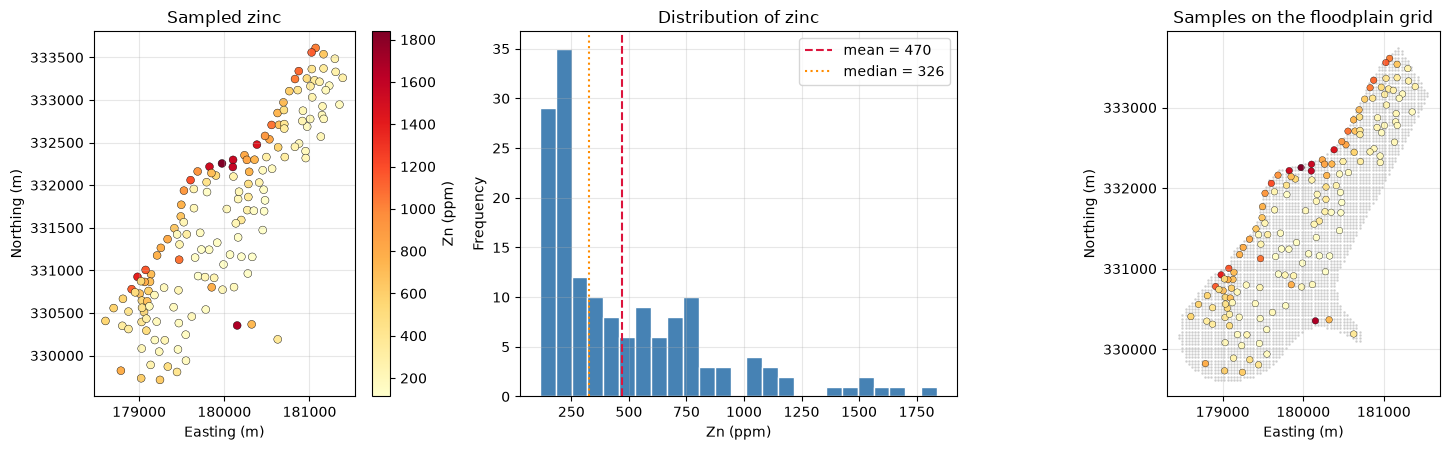

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

sc = axes[0].scatter(
    df["x"], df["y"], c=zinc, cmap="YlOrRd", s=32,
    edgecolors="k", linewidths=0.3,
)
plt.colorbar(sc, ax=axes[0], label="Zn (ppm)", fraction=0.046, pad=0.04)
axes[0].set_title("Sampled zinc")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")
axes[0].set_aspect("equal")

axes[1].hist(zinc, bins=25, color="steelblue", edgecolor="white")
axes[1].axvline(zinc.mean(), color="crimson", ls="--",
                label=f"mean = {zinc.mean():.0f}")
axes[1].axvline(np.median(zinc), color="darkorange", ls=":",
                label=f"median = {np.median(zinc):.0f}")
axes[1].set_title("Distribution of zinc")
axes[1].set_xlabel("Zn (ppm)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

axes[2].scatter(grid["x"], grid["y"], s=2, c="0.8", marker=".")
axes[2].scatter(df["x"], df["y"], c=zinc, cmap="YlOrRd", s=22,
                edgecolors="k", linewidths=0.25)
axes[2].set_title("Samples on the floodplain grid")
axes[2].set_xlabel("Easting (m)")
axes[2].set_ylabel("Northing (m)")
axes[2].set_aspect("equal")

plt.tight_layout()
plt.show()


***
## 8. Choose Cutoffs and Build Indicators

Nine quantiles (10%, 20%, …, 90%) give a ccdf that is dense enough for an
E-type integral without wasting a cutoff on the degenerate 0% / 100%
indicators. At each $z_k$ the global exceedance rate $p_k$ sets the indicator
sill $p_k(1-p_k)$.


,quantile,threshold_ppm,p(Zn >= z_k),indicator_sill p(1-p),n_exceed
0,0.1,152.8,0.897,0.0926,139
1,0.2,186.8,0.800,0.1600,124
2,0.3,207.2,0.697,0.2113,108
3,0.4,246.4,0.600,0.2400,93
4,0.5,326.0,0.503,0.2500,78
5,0.6,439.6,0.400,0.2400,62
6,0.7,589.8,0.303,0.2113,47
7,0.8,737.2,0.200,0.1600,31
8,0.9,986.4,0.103,0.0926,16


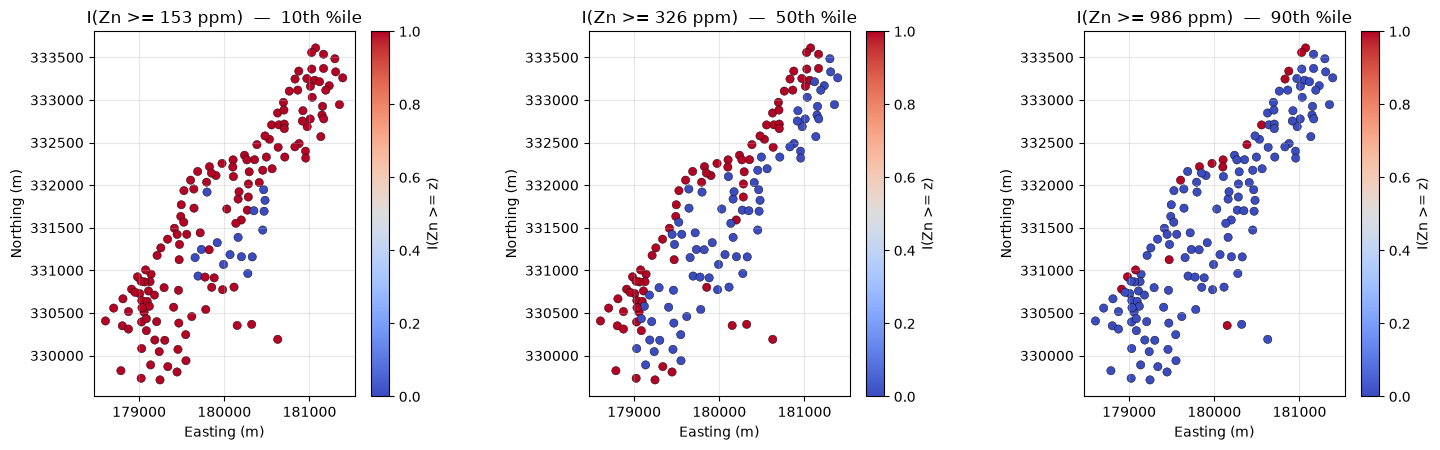

In [4]:
quantiles = np.arange(0.10, 1.00, 0.10)
thresholds = np.quantile(zinc, quantiles)
p_exceed = np.array([(zinc >= t).mean() for t in thresholds])

cutoff_tbl = pd.DataFrame({
    "quantile": quantiles,
    "threshold_ppm": thresholds.round(1),
    "p(Zn >= z_k)": p_exceed.round(3),
    "indicator_sill p(1-p)": (p_exceed * (1 - p_exceed)).round(4),
    "n_exceed": [(zinc >= t).sum() for t in thresholds],
})
display(cutoff_tbl)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
show_idx = [0, 4, 8]
for ax, i in zip(axes, show_idx):
    t = thresholds[i]
    ind = (zinc >= t).astype(float)
    sc = ax.scatter(
        df["x"], df["y"], c=ind, cmap="coolwarm", s=36,
        edgecolors="k", linewidths=0.3, vmin=0, vmax=1,
    )
    plt.colorbar(sc, ax=ax, label="I(Zn >= z)", fraction=0.046, pad=0.04)
    ax.set_title(f"I(Zn >= {t:.0f} ppm)  —  {int(quantiles[i]*100)}th %ile")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()


***
## 9. Empirical Indicator Variograms

`fit_indicator_variogram` returns the Matheron estimator at each cutoff. A
spherical model is then least-squares fitted with the nugget / sill boxed to
the binary range $[0, 0.3]$ and the range boxed to a multiple of the median
pairwise distance. The fitted $(c_0, c, a)$ triples become
`variogram_params` for kriging.


In [5]:
def spherical_variogram(h, nugget, sill, rng):
    """Spherical variogram model γ(h) = nugget + sill * sph(h / range)."""
    h = np.asarray(h, dtype=float)
    gamma = np.full_like(h, nugget + sill)
    mask = h < rng
    hr = h[mask] / rng
    gamma[mask] = nugget + sill * (1.5 * hr - 0.5 * hr ** 3)
    return gamma


from scipy.spatial.distance import pdist

maxlag = float(np.percentile(pdist(coords), 50))
n_lags = 12
variogram_params = {}
empirical = {}

for t in thresholds:
    lags, gamma_exp = fit_indicator_variogram(
        coords, zinc, threshold=t, maxlag=maxlag, n_lags=n_lags,
    )
    empirical[t] = (lags, gamma_exp)

    sill0 = float(np.nanvar((zinc >= t).astype(float)))
    x0 = np.array([0.01, max(sill0, 0.02), maxlag * 0.5])
    bounds = [(0.0, 0.3), (1e-4, 0.3), (50.0, maxlag * 2.0)]

    def objective(params, lags=lags, gamma_exp=gamma_exp):
        pred = spherical_variogram(lags, *params)
        mask = np.isfinite(gamma_exp)
        if not np.any(mask):
            return 1e6
        return np.sum((pred[mask] - gamma_exp[mask]) ** 2)

    res = minimize(objective, x0, bounds=bounds, method="L-BFGS-B")
    variogram_params[t] = tuple(res.x if res.success else x0)

fit_tbl = pd.DataFrame(
    [
        {
            "threshold_ppm": round(t, 1),
            "nugget": params[0],
            "sill": params[1],
            "range_m": params[2],
            "total_sill": params[0] + params[1],
        }
        for t, params in variogram_params.items()
    ]
)
print(f"maxlag (median pairwise distance): {maxlag:.0f} m")
display(fit_tbl.round(3))


maxlag (median pairwise distance): 1373 m


,threshold_ppm,nugget,sill,range_m,total_sill
0,152.8,0.014,0.151,1652.011,0.165
1,186.8,0.023,0.164,686.333,0.187
2,207.2,0.087,0.146,686.333,0.233
3,246.4,0.056,0.211,686.333,0.267
4,326.0,0.082,0.190,686.333,0.271
5,439.6,0.087,0.172,686.333,0.259
6,589.8,0.110,0.119,686.333,0.229
7,737.2,0.057,0.122,686.333,0.179
8,986.4,0.064,0.030,686.333,0.095


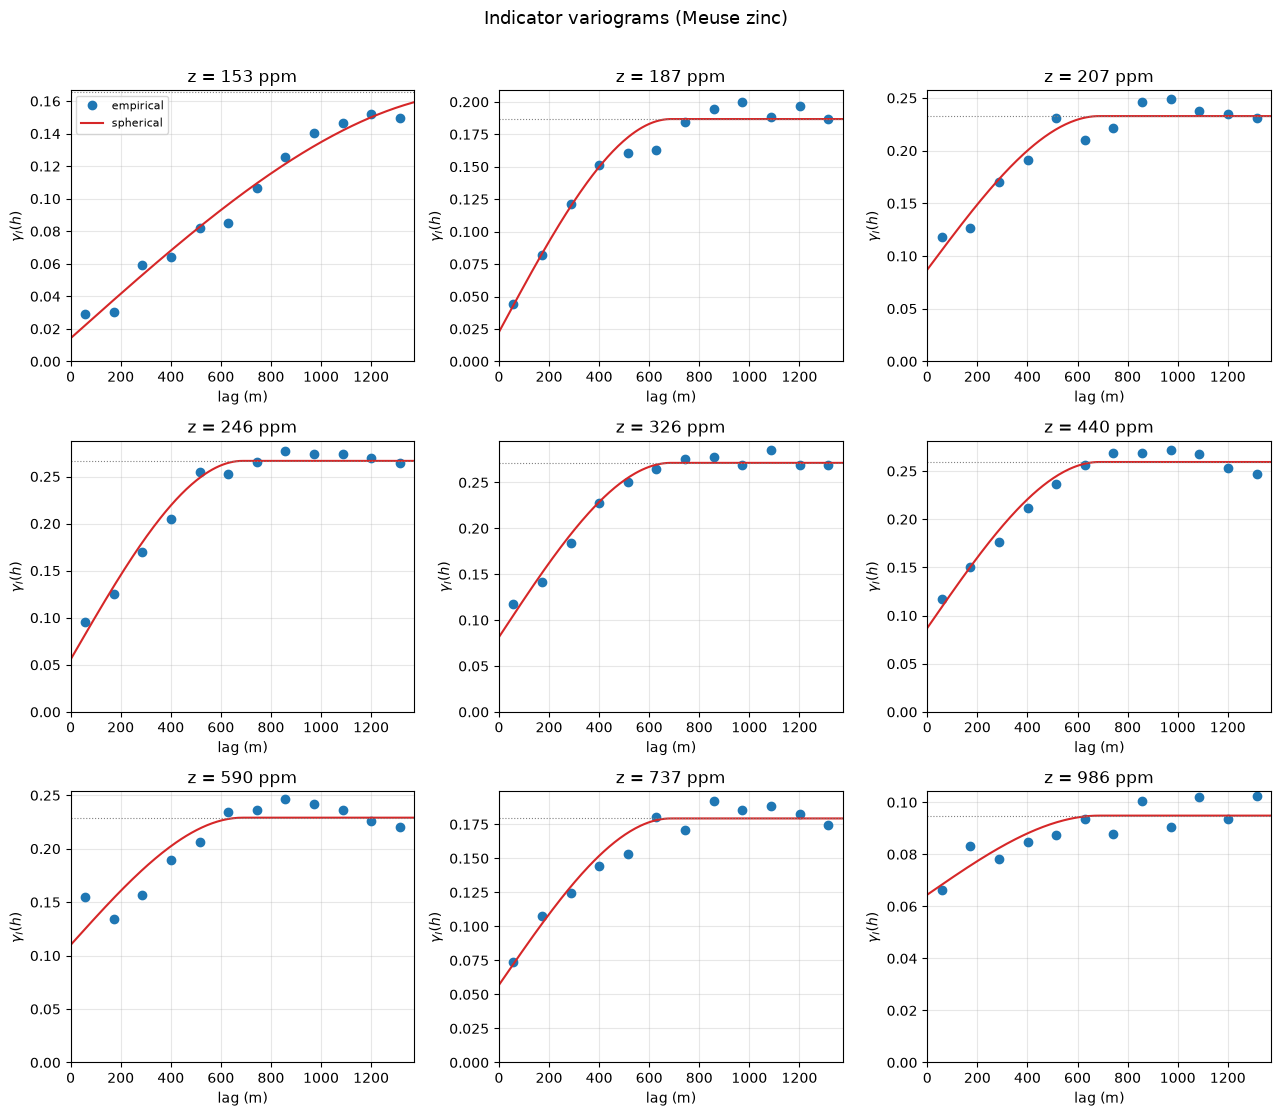

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
h_fine = np.linspace(0, maxlag, 200)
for ax, t in zip(axes.flat, thresholds):
    lags, gamma_exp = empirical[t]
    nugget, sill, rng = variogram_params[t]
    ax.plot(lags, gamma_exp, "o", color="tab:blue", label="empirical")
    ax.plot(h_fine, spherical_variogram(h_fine, nugget, sill, rng),
            "-", color="tab:red", label="spherical")
    ax.axhline(nugget + sill, color="0.5", ls=":", lw=0.8)
    ax.set_title(f"z = {t:.0f} ppm")
    ax.set_xlabel("lag (m)")
    ax.set_ylabel(r"$\gamma_I(h)$")
    ax.set_xlim(0, maxlag)
    ax.set_ylim(bottom=0)
axes.flat[0].legend(fontsize=8)
fig.suptitle("Indicator variograms (Meuse zinc)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


***
## 10. Cross-Validation (Brier Score)

The Brier score is the mean squared error of a probability forecast,

$$
\mathrm{BS}
= \frac{1}{n}\sum_{i=1}^{n}
\big(I_i - p_i\big)^2,
$$

so 0 is perfect and the no-skill baseline (always predict the global rate
$p_k$) equals $p_k(1-p_k)$ — the indicator variance. `IndicatorKrigingCV`
refits IK on each of 5 shuffled folds and scores the held-out probabilities.
A useful model lies **below** the dashed baseline at every cutoff.


In [7]:
ik_cv_model = IndicatorKriging(
    cov_model="spherical",
    max_neighbors=12,
    search_radius=maxlag * 0.8,
    use_gpu=USE_GPU,
)
cv = IndicatorKrigingCV(n_splits=5, random_state=42)
cv_result = cv.validate(ik_cv_model, coords, zinc, thresholds, variogram_params)
brier_avg = cv_result["brier_scores"]

baseline_brier = {t: p * (1 - p) for t, p in zip(thresholds, p_exceed)}

brier_tbl = pd.DataFrame({
    "threshold_ppm": [round(t, 1) for t in thresholds],
    "IK Brier": [brier_avg[t] for t in thresholds],
    "no-skill Brier": [baseline_brier[t] for t in thresholds],
})
brier_tbl["skill"] = 1.0 - brier_tbl["IK Brier"] / brier_tbl["no-skill Brier"]
display(brier_tbl.round(4))

print("Mean IK Brier :", f"{brier_tbl['IK Brier'].mean():.4f}")
print("Mean baseline :", f"{brier_tbl['no-skill Brier'].mean():.4f}")


,threshold_ppm,IK Brier,no-skill Brier,skill
0,152.8,0.0374,0.0926,0.5965
1,186.8,0.1113,0.1600,0.3041
2,207.2,0.1384,0.2113,0.3451
3,246.4,0.1223,0.2400,0.4902
4,326.0,0.1174,0.2500,0.5306
5,439.6,0.1228,0.2400,0.4885
6,589.8,0.1273,0.2113,0.3975
7,737.2,0.1030,0.1600,0.3565
8,986.4,0.0907,0.0926,0.0199


Mean IK Brier : 0.1078
Mean baseline : 0.1842


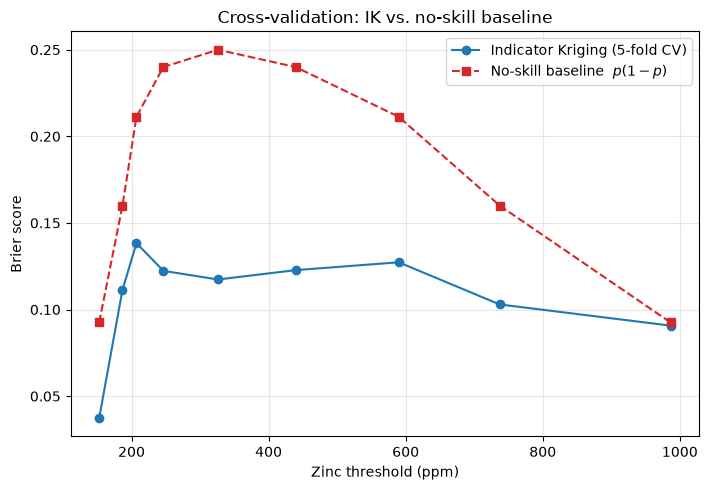

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 5))
ax.plot(thresholds, [brier_avg[t] for t in thresholds],
        "o-", color="tab:blue", label="Indicator Kriging (5-fold CV)")
ax.plot(thresholds, [baseline_brier[t] for t in thresholds],
        "s--", color="tab:red", label="No-skill baseline  $p(1-p)$")
ax.set_xlabel("Zinc threshold (ppm)")
ax.set_ylabel("Brier score")
ax.set_title("Cross-validation: IK vs. no-skill baseline")
ax.legend()
plt.tight_layout()
plt.show()


***
## 11. Predict Exceedance Probabilities on the Grid

Fit `IndicatorKriging` on all 155 samples and predict $P[\mathrm{Zn} \ge z_k]$
at every floodplain grid node. The three maps below are the 10th, 50th, and
90th percentile cutoffs — low, typical, and high-grade zinc.


In [9]:
ik = IndicatorKriging(
    cov_model="spherical",
    max_neighbors=12,
    search_radius=maxlag * 0.8,
    use_gpu=USE_GPU,
)
ik.fit(coords, zinc)
probabilities = ik.predict(coords_grid, thresholds.tolist(), variogram_params)

for t in thresholds:
    p = probabilities[t]
    print(
        f"z = {t:7.1f} ppm   "
        f"P in [{np.nanmin(p):.3f}, {np.nanmax(p):.3f}]   "
        f"mean = {np.nanmean(p):.3f}   "
        f"nans = {np.isnan(p).sum()}"
    )


z =   152.8 ppm   P in [0.000, 1.000]   mean = 0.835   nans = 0
z =   186.8 ppm   P in [0.000, 1.000]   mean = 0.691   nans = 0
z =   207.2 ppm   P in [0.004, 1.000]   mean = 0.587   nans = 0
z =   246.4 ppm   P in [0.000, 1.000]   mean = 0.469   nans = 0
z =   326.0 ppm   P in [0.000, 1.000]   mean = 0.389   nans = 0
z =   439.6 ppm   P in [0.000, 1.000]   mean = 0.301   nans = 0
z =   589.8 ppm   P in [0.000, 0.953]   mean = 0.226   nans = 0
z =   737.2 ppm   P in [0.000, 0.991]   mean = 0.150   nans = 0
z =   986.4 ppm   P in [0.000, 0.558]   mean = 0.068   nans = 0


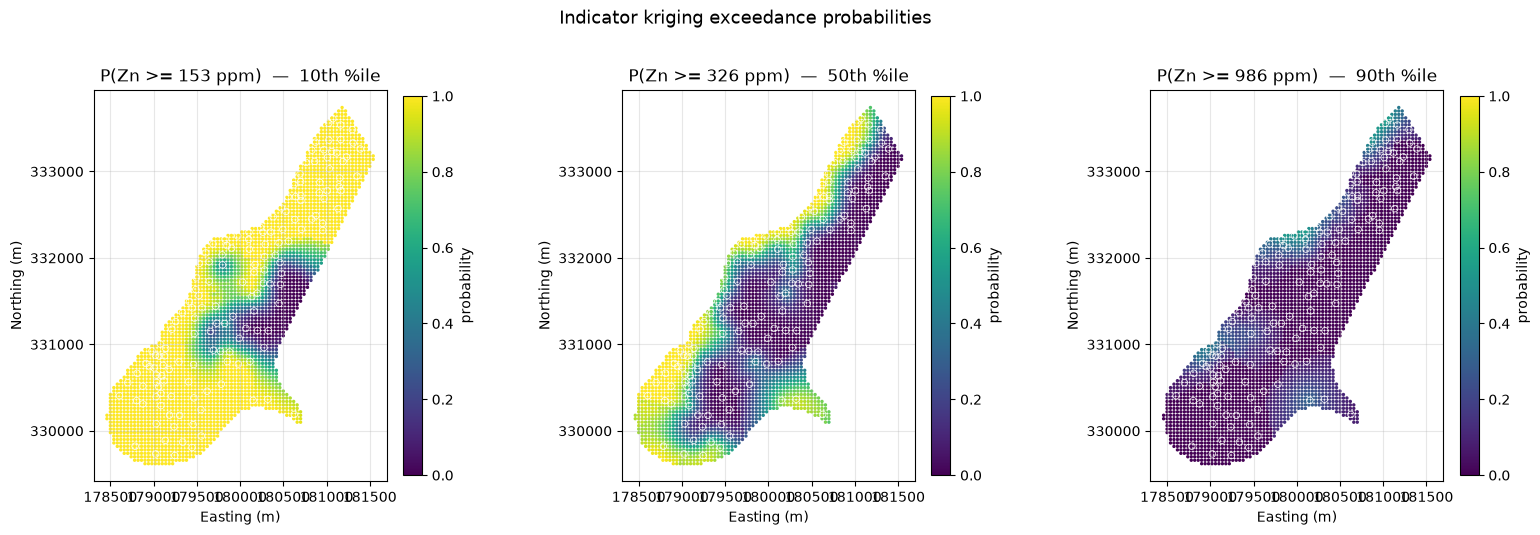

In [10]:
show = [
    (0, f"P(Zn >= {thresholds[0]:.0f} ppm)  —  10th %ile"),
    (4, f"P(Zn >= {thresholds[4]:.0f} ppm)  —  50th %ile"),
    (8, f"P(Zn >= {thresholds[8]:.0f} ppm)  —  90th %ile"),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
for ax, (i, title) in zip(axes, show):
    t = thresholds[i]
    sc = ax.scatter(
        grid["x"], grid["y"], c=probabilities[t],
        cmap="viridis", s=8, marker=".", vmin=0, vmax=1,
    )
    ax.scatter(
        df["x"], df["y"], facecolors="none", edgecolors="w",
        s=22, linewidths=0.5,
    )
    plt.colorbar(sc, ax=ax, label="probability", fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
fig.suptitle("Indicator kriging exceedance probabilities", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


***
## 12. E-type Estimate of Zinc

Integrating the nine probability maps with
`compute_etype_from_probabilities` (trapezoid rule, lower tail from 0 ppm,
upper tail to the sample maximum) gives the E-type zinc map — the local
conditional mean, without a Gaussian assumption.


E-type Zn (ppm):  min 76.6   mean 396.7   max 1135.4
Sample zinc mean: 469.7 ppm


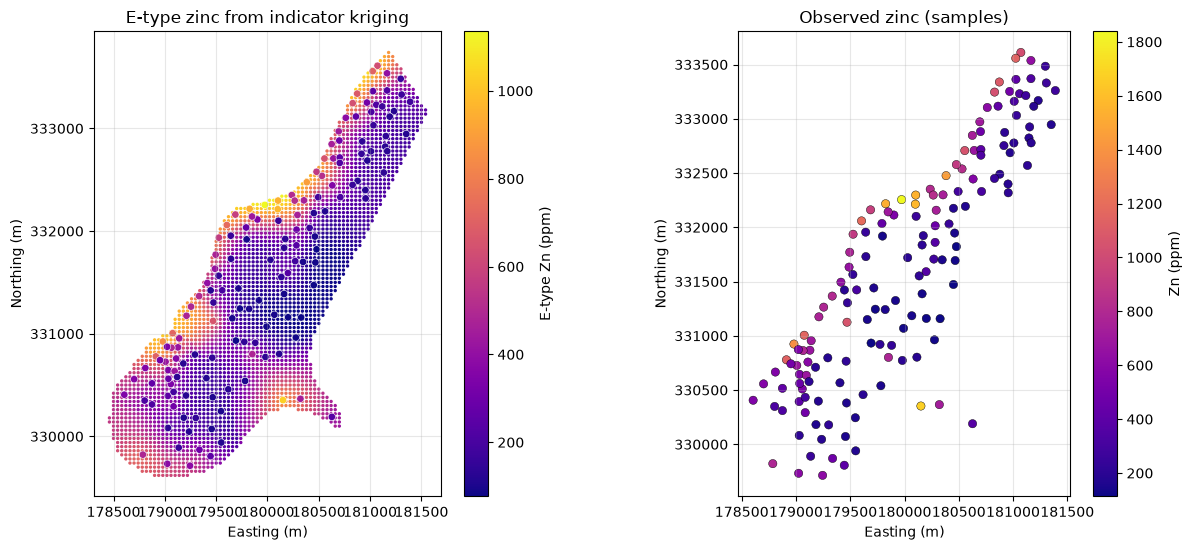

In [11]:
prob_arrays = [probabilities[t] for t in thresholds]
etype = compute_etype_from_probabilities(
    thresholds, prob_arrays, z_min=0.0, z_max=float(zinc.max()),
)

print(
    f"E-type Zn (ppm):  min {np.nanmin(etype):.1f}   "
    f"mean {np.nanmean(etype):.1f}   "
    f"max {np.nanmax(etype):.1f}"
)
print(f"Sample zinc mean: {zinc.mean():.1f} ppm")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))

sc0 = axes[0].scatter(
    grid["x"], grid["y"], c=etype, cmap="plasma", s=8, marker=".",
)
axes[0].scatter(
    df["x"], df["y"], c=zinc, cmap="plasma", s=28,
    edgecolors="w", linewidths=0.4,
)
plt.colorbar(sc0, ax=axes[0], label="E-type Zn (ppm)", fraction=0.046, pad=0.04)
axes[0].set_aspect("equal")
axes[0].set_title("E-type zinc from indicator kriging")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")

sc1 = axes[1].scatter(
    df["x"], df["y"], c=zinc, cmap="plasma", s=36,
    edgecolors="k", linewidths=0.3,
)
plt.colorbar(sc1, ax=axes[1], label="Zn (ppm)", fraction=0.046, pad=0.04)
axes[1].set_aspect("equal")
axes[1].set_title("Observed zinc (samples)")
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()


***
## 13. CPU vs GPU IK Timing

The 155-sample Meuse survey is too small for a GPU comparison: the batched IK solve is a stack of tiny $(k+1)\times(k+1)$ systems, and host→device copies dominate. Here we **simulate a Meuse-like zinc field** with Sequential Gaussian Simulation (`pygstat.sgsim`) so that $n_{\mathrm{train}} > 5{,}000$, then time **k-nearest-neighbor** indicator kriging (`search_radius=None`) on **CPU** (`use_gpu=False`) versus **GPU** (`use_gpu=True`).

Simulation recipe (conditioned on the real 155 samples):

1. Draw $n_{\mathrm{train}} = 8{,}000$ random locations in the Meuse bounding box.
2. Simulate $\log(\mathrm{zinc})$ with `sgsim` (exponential variogram, practical range 900 m, as in tutorial 18) and back-transform with $\exp(\cdot)$.
3. Draw a separate prediction set (no values needed — IK only needs coordinates).

Unlike global ordinary kriging, IK's GPU work scales with **$n_{\mathrm{pred}}$** (one stacked solve of shape `(n_pred, k+1, k+1)` per cutoff), not $n_{\mathrm{train}}^3$. Training size is therefore held at 8{,}000 and we vary $n_{\mathrm{pred}}$. Variogram parameters are held fixed (binary spherical: nugget 0.02, partial sill 0.20, range 900 m) so fitting $\gamma_I$ is **not** in the times. Three quartile cutoffs of the simulated zinc are kriged.

Each timing is the **median** of three `fit` + `predict` calls after a short GPU warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel here, the GPU column is skipped.


Simulating 8,000 Meuse-like zinc locations with sgsim
  conditioning : 155 samples from data/meuse.csv
  vario        : azimuth=0, nugget=0.05, range=900 m, exponential, log(zinc) space
  sgsim wall   : 58.4 s  (not included in IK times)
  simulated Zn : [25, 8046] ppm  (Meuse observed [113, 1839])
  cutoffs      : [224.0, 424.1, 888.2] ppm  (quartiles)

GPU usable : True
Repeats    : 3  (median wall time of IK fit + predict, k-NN)
n_train    : 8000  (sgsim Meuse-like zinc)
n_pred     : [500, 1000, 2000, 4000, 8000]  (random locations in the Meuse bbox)
thresholds : 3 quartile cutoffs; max_neighbors=12

      dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
Meuse (sgsim)     8000     500      20.7      14.1   1.46×   True
Meuse (sgsim)     8000    1000      38.1      17.0   2.24×   True
Meuse (sgsim)     8000    2000      84.7      23.5   3.61×   True
Meuse (sgsim)     8000    4000     179.1      36.4   4.92×   True
Meuse (sgsim)     8000    8000     351.7      62.8   5.60× 

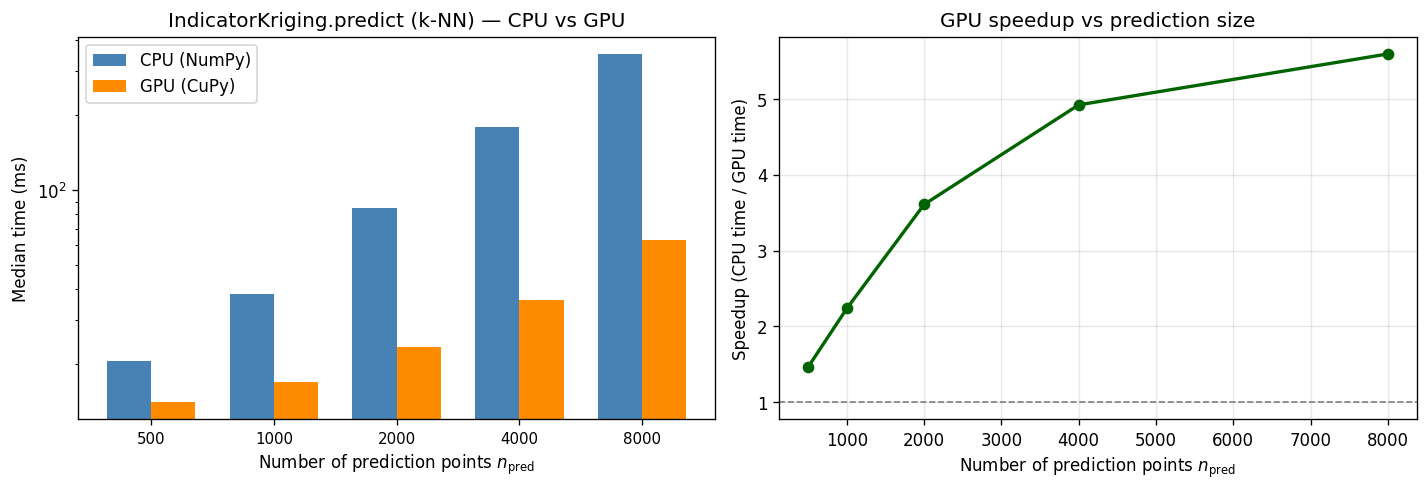

In [22]:
import time

from pygstat import sgsim

N_REPEATS = 3
N_TRAIN = 8000
PRED_SIZES = [500, 1000, 2000, 4000, 8000]
N_PRED_MAX = max(PRED_SIZES)
rng_sim = np.random.default_rng(42)

pad = 50.0
xmin, xmax = float(coords[:, 0].min()) - pad, float(coords[:, 0].max()) + pad
ymin, ymax = float(coords[:, 1].min()) - pad, float(coords[:, 1].max()) + pad

xy_train_all = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_TRAIN, 2))
xy_pred_all = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_PRED_MAX, 2))

df_cond = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "log_zinc": np.log(zinc),
})
vario_sgs = [0, 0.05, 900.0, 900.0, float(np.var(np.log(zinc))), "exponential"]

print(f"Simulating {N_TRAIN:,} Meuse-like zinc locations with sgsim")
print(f"  conditioning : {len(zinc)} samples from data/meuse.csv")
print(f"  vario        : azimuth=0, nugget=0.05, range=900 m, exponential, log(zinc) space")
t_sim0 = time.perf_counter()
sims = sgsim(
    xy_train_all, df_cond, "x", "y", "log_zinc",
    num_points=12, vario=vario_sgs, radius=2000,
    kriging_type="ordinary", nsim=1, itrans=False, seed=42, quiet=True,
)
z_train_all = np.exp(np.asarray(sims[0], dtype=float))
print(f"  sgsim wall   : {time.perf_counter() - t_sim0:.1f} s  (not included in IK times)")
print(f"  simulated Zn : [{z_train_all.min():.0f}, {z_train_all.max():.0f}] ppm"
      f"  (Meuse observed [{zinc.min():.0f}, {zinc.max():.0f}])")

thresholds_sim = [float(t) for t in np.quantile(z_train_all, [0.25, 0.50, 0.75])]
variogram_params_sim = {t: (0.02, 0.20, 900.0) for t in thresholds_sim}
print(f"  cutoffs      : {[round(t, 1) for t in thresholds_sim]} ppm  (quartiles)")
print()


def _time_ik(xy_train, z_train, xy_pred, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of IndicatorKriging.fit + predict (k-NN, search_radius=None)."""
    if warmup:
        k_tr = min(40, len(xy_train))
        k_pr = min(40, len(xy_pred))
        IndicatorKriging(
            cov_model="spherical", max_neighbors=12, search_radius=None, use_gpu=use_gpu,
        ).fit(xy_train[:k_tr], z_train[:k_tr]).predict(
            xy_pred[:k_pr], thresholds_sim, variogram_params_sim
        )
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        ik_m = IndicatorKriging(
            cov_model="spherical", max_neighbors=12, search_radius=None, use_gpu=use_gpu,
        )
        ik_m.fit(xy_train, z_train)
        last = ik_m.predict(xy_pred, thresholds_sim, variogram_params_sim)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


def _probs_match(a, b):
    return all(
        np.allclose(a[t], b[t], rtol=1e-4, atol=1e-4, equal_nan=True)
        for t in thresholds_sim
    )


print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of IK fit + predict, k-NN)")
print(f"n_train    : {N_TRAIN}  (sgsim Meuse-like zinc)")
print(f"n_pred     : {PRED_SIZES}  (random locations in the Meuse bbox)")
print(f"thresholds : {len(thresholds_sim)} quartile cutoffs; max_neighbors=12")
print()

rows = []
for n_pred in PRED_SIZES:
    xy_pr = xy_pred_all[:n_pred]
    cpu_t, pred_cpu = _time_ik(xy_train_all, z_train_all, xy_pr, use_gpu=False)
    row = {
        "dataset": "Meuse (sgsim)",
        "n_train": N_TRAIN,
        "n_pred": n_pred,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_GPU:
        gpu_t, pred_gpu = _time_ik(xy_train_all, z_train_all, xy_pr, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        row["match"] = bool(_probs_match(pred_cpu, pred_gpu))
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_pred"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [str(int(n)) for n in n_vals]

x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel("Number of prediction points $n_{\\mathrm{pred}}$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("IndicatorKriging.predict (k-NN) — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel("Number of prediction points $n_{\\mathrm{pred}}$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs prediction size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Exceedance probabilities from the two backends should **match** (`match = True`). The GPU speedup comes from the batched $(n_{\mathrm{pred}}, k+1, k+1)$ OK solve at each cutoff, not from SGS (simulation is CPU sequential and is excluded from the times). Small $n_{\mathrm{pred}}$ can show little GPU gain because kernel-launch overhead dominates; as the prediction set grows the stacked solve keeps the GPU several times faster. Use `use_gpu=USE_GPU` with `search_radius=None` so the same cells run on a laptop CPU or a CUDA workstation without edits.


***
## 14. Summary and Conclusions

- **Indicator kriging** estimates $P[Z \ge z_k]$ by ordinary kriging of the
  0/1 exceedance indicators. It is the right interpolator when the grade is
  skewed, when a regulatory cutoff matters more than the mean, or when a
  Gaussian OK probability map would be misleading.
- **`pygstat.IndicatorKriging`** implements that OK system in 2-D with a local
  search neighbourhood and per-threshold spherical / exponential covariance —
  the ordinary-kriging branch of GSLIB `ik3d`.
- On **Meuse zinc**, nine quantile cutoffs (10%–90%) produced well-behaved
  indicator variograms. Extreme cutoffs were avoided because the indicator
  variance $p(1-p)$ collapses and the empirical $\gamma_I$ becomes noisy.
- **5-fold Brier scores** sat below the no-skill baseline $p(1-p)$ at every
  cutoff, so the spatial model is adding skill, not just reproducing the
  histogram.
- The **probability maps** concentrate high $P(\mathrm{Zn} \ge z_{90})$ along
  the river, matching the sample pattern, while the 10th-percentile map is
  high almost everywhere (most of the floodplain exceeds the low cutoff).
- The **E-type map** (`compute_etype_from_probabilities`) is a distribution-free
  mean-grade surface. It is smoother than any single sequential-indicator
  realization (`sisim`) and is the IK analogue of an ordinary-kriging grade map.
- **CPU / GPU.** k-NN indicator kriging (`search_radius=None`, `use_gpu=USE_GPU`)
  was timed on an **sgsim** Meuse-like zinc field with 8{,}000 training locations.
  The GPU batched `(n_pred, k+1, k+1)` solve is the accelerated step; SGS itself is sequential and was not timed.

| Object | Role in this notebook |
|---|---|
| `fit_indicator_variogram` | Empirical $\gamma_I(h; z_k)$ |
| `IndicatorKriging` | Ordinary IK probabilities $P[Z \ge z_k]$ |
| `IndicatorKrigingCV` | 5-fold Brier-score validation |
| `compute_etype_from_probabilities` | $Z_E = \int P[Z \ge z]\,dz$ |


***
## 15. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Deutsch, C.V. & Journel, A.G. (1998). *GSLIB: Geostatistical Software Library and User's Guide* (2nd ed.). Oxford University Press. | Reference for `ik3d`, order-relation corrections, and E-type estimates |
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | Indicator coding, per-threshold variograms, E-type vs. simulation |
| Chilès, J.-P. & Delfiner, P. (2012). *Geostatistics: Modeling Spatial Uncertainty* (2nd ed.). Wiley. | Indicator formalism and conditional distributions |
| Isaaks, E.H. & Srivastava, R.M. (1989). *An Introduction to Applied Geostatistics*. Oxford. | Worked indicator examples |

### Key papers

| Paper | Contribution |
|---|---|
| Journel, A.G. (1983). Nonparametric estimation of spatial distributions. *Mathematical Geology* 15, 445–468. | Indicator approach to local ccdfs |
| Brier, G.W. (1950). Verification of forecasts expressed in terms of probability. *Monthly Weather Review* 78, 1–3. | Brier score for probability forecasts |
| Journel, A.G. & Huijbregts, C.J. (1978). *Mining Geostatistics*. Academic Press. | Ordinary kriging system reused at each cutoff |

### In this library

| Object | Role |
|---|---|
| `pygstat.IndicatorKriging` | Ordinary indicator kriging (exceedance coding $I(Z \ge z_k)$; `use_gpu` for k-NN) |
| `pygstat.fit_indicator_variogram` | Empirical indicator semivariogram |
| `pygstat.IndicatorKrigingCV` | K-fold Brier-score cross-validation |
| `pygstat.compute_etype_from_probabilities` | E-type (conditional mean) from IK probabilities |
| `pygstat.sgsim` | Sequential Gaussian simulation used in §13 to build $n=8{,}000$ Meuse-like zinc |
| `pygstat.sisim` | Sequential indicator simulation (GSLIB `sisim.for` port) |
| `gslib90sc/ik3d.for` | Original Fortran indicator-kriging driver |
